In [2]:
#Carga del dataset para la tarea
#PAQUETES NECESARIOS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from google.colab import files

#CARGA
uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])

Saving heart.csv to heart.csv


### P1

(a)

In [4]:
#paquetes utiles
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

Valores propios (λ_j):
  λ1 = 1.8305
  λ2 = 1.2948
  λ3 = 0.8735
  λ4 = 0.8336
  λ5 = 0.6438
  λ6 = 0.5319

Varianza explicada (%): [30.47 21.55 14.54 13.87 10.72  8.85]
Varianza acumulada (%): [ 30.47  52.02  66.56  80.43  91.15 100.  ]

Componentes para ≥90% de varianza: 5


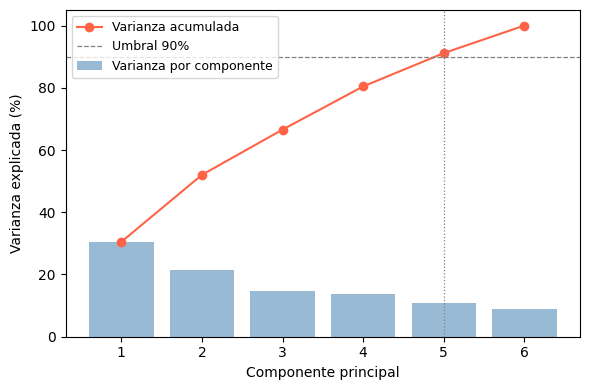

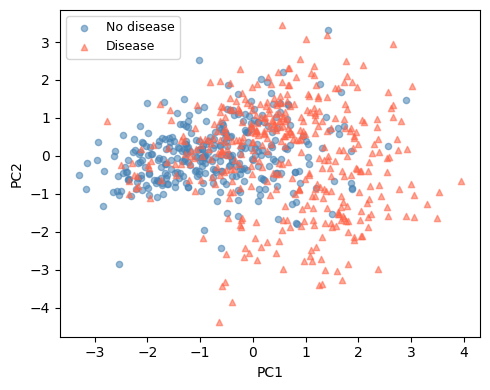


Loadings PC1 y PC2:
                PC1     PC2
Age          0.5569  0.1783
RestingBP    0.3081  0.4513
Cholesterol -0.3035  0.6389
FastingBS    0.3770 -0.3570
MaxHR       -0.5263  0.0873
Oldpeak      0.2894  0.4704


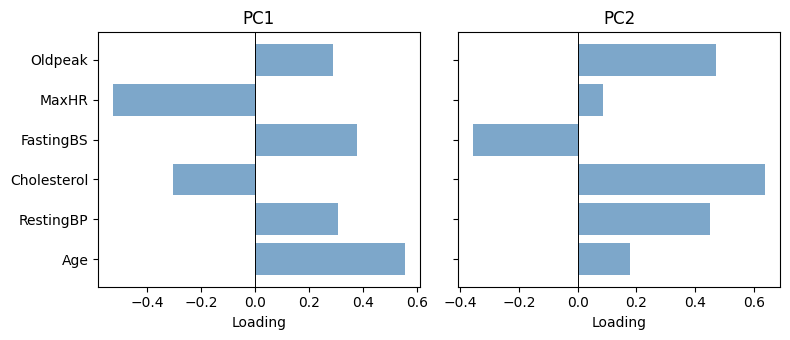

In [5]:
SEED = 42

df = pd.read_csv('heart.csv')
df = pd.get_dummies(df, drop_first=True)

X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Mismas columnas que Tarea 4
cols_numericas = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']

scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[cols_numericas])
X_test_num  = scaler.transform(X_test[cols_numericas])

# PCA sobre variables numéricas estandarizadas
pca = PCA(random_state=SEED)
pca.fit(X_train_num)

eigenvalues     = pca.explained_variance_
explained_ratio = pca.explained_variance_ratio_
cumulative_var  = np.cumsum(explained_ratio)

print("Valores propios (λ_j):")
for i, lam in enumerate(eigenvalues, 1):
    print(f"  λ{i} = {lam:.4f}")

print("\nVarianza explicada (%):", np.round(explained_ratio * 100, 2))
print("Varianza acumulada (%):", np.round(cumulative_var * 100, 2))

n_90 = int(np.argmax(cumulative_var >= 0.90)) + 1
print(f"\nComponentes para ≥90% de varianza: {n_90}")

# Gráfico varianza explicada y acumulada
fig, ax = plt.subplots(figsize=(6, 4))
comps = np.arange(1, len(eigenvalues) + 1)
ax.bar(comps, explained_ratio * 100, alpha=0.55, color='steelblue',
       label='Varianza por componente')
ax.plot(comps, cumulative_var * 100, marker='o', color='tomato',
        linewidth=1.5, label='Varianza acumulada')
ax.axhline(90, color='gray', linestyle='--', linewidth=0.9, label='Umbral 90%')
ax.axvline(n_90, color='gray', linestyle=':', linewidth=0.9)
ax.set_xlabel('Componente principal')
ax.set_ylabel('Varianza explicada (%)')
ax.set_xticks(comps)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('pca_variance.pdf')
plt.show()

# Proyección 2D coloreada por HeartDisease
X_train_pca = pca.transform(X_train_num)

fig, ax = plt.subplots(figsize=(5, 4))
for label, color, marker, name in [
    (0, 'steelblue', 'o', 'No disease'),
    (1, 'tomato',    '^', 'Disease')
]:
    mask = y_train.values == label
    ax.scatter(X_train_pca[mask, 0], X_train_pca[mask, 1],
               c=color, marker=marker, alpha=0.55, s=20, label=name)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('pca_scatter.pdf')
plt.show()

# Inspección de loadings (vectores propios)
loadings = pd.DataFrame(
    pca.components_[:2].T,
    index=cols_numericas,
    columns=['PC1', 'PC2']
)
print("\nLoadings PC1 y PC2:")
print(loadings.round(4))

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5), sharey=True)
for ax, pc in zip(axes, ['PC1', 'PC2']):
    ax.barh(cols_numericas, loadings[pc], color='steelblue', alpha=0.7)
    ax.axvline(0, color='black', linewidth=0.7)
    ax.set_title(pc)
    ax.set_xlabel('Loading')
plt.tight_layout()
plt.savefig('pca_loadings.pdf')
plt.show()

(b)

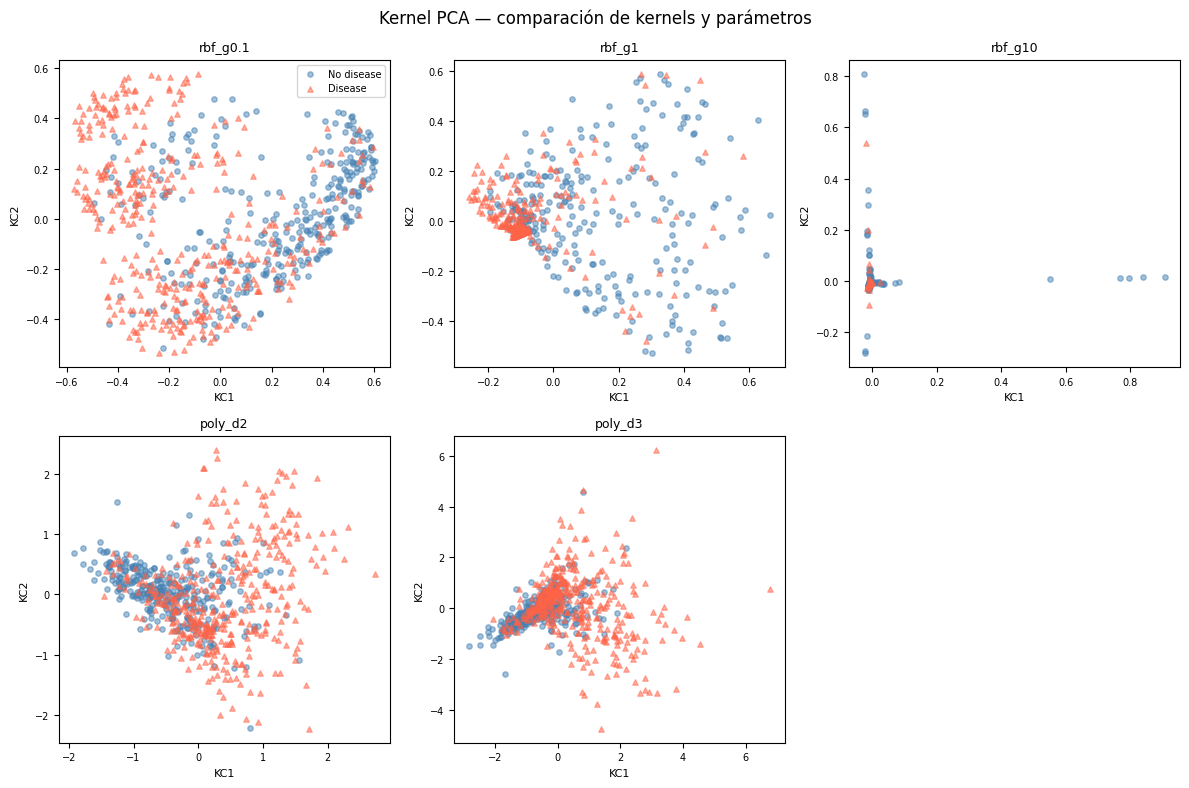

In [7]:
from sklearn.decomposition import KernelPCA

# kernels a comparar: rbf y poly
kernels = {
    'rbf_g0.1':  KernelPCA(n_components=2, kernel='rbf',  gamma=0.1,  random_state=SEED),
    'rbf_g1':    KernelPCA(n_components=2, kernel='rbf',  gamma=1.0,  random_state=SEED),
    'rbf_g10':   KernelPCA(n_components=2, kernel='rbf',  gamma=10.0, random_state=SEED),
    'poly_d2':   KernelPCA(n_components=2, kernel='poly', degree=2,   random_state=SEED),
    'poly_d3':   KernelPCA(n_components=2, kernel='poly', degree=3,   random_state=SEED),
}

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for ax, (name, kpca) in zip(axes, kernels.items()):
    X_kpca = kpca.fit_transform(X_train_num)

    for label, color, marker, lname in [
        (0, 'steelblue', 'o', 'No disease'),
        (1, 'tomato', '^', 'Disease')
    ]:
        mask = y_train.values == label
        ax.scatter(X_kpca[mask, 0], X_kpca[mask, 1],
                   c=color, marker=marker, alpha=0.5,
                   s=15, label=lname)

    ax.set_title(name, fontsize=9)
    ax.set_xlabel('KC1', fontsize=8)
    ax.set_ylabel('KC2', fontsize=8)
    ax.tick_params(labelsize=7)

# eliminar el sexto subplot vacío
fig.delaxes(axes[5])

axes[0].legend(fontsize=7)

plt.suptitle('Kernel PCA — comparación de kernels y parámetros', fontsize=12)
plt.tight_layout()
plt.show()

(c)

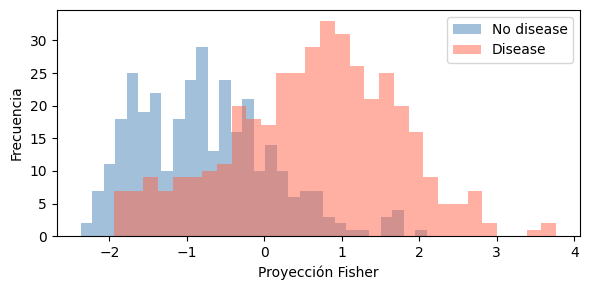

In [8]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda_p1 = LinearDiscriminantAnalysis()
lda_p1.fit(X_train_num, y_train)

X_train_lda = lda_p1.transform(X_train_num)  # proyección 1D

fig, ax = plt.subplots(figsize=(6, 3))
for label, color, name in [(0, 'steelblue', 'No disease'), (1, 'tomato', 'Disease')]:
    mask = y_train.values == label
    ax.hist(X_train_lda[mask, 0], bins=30, alpha=0.5, color=color, label=name)
ax.set_xlabel('Proyección Fisher')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.savefig('lda_hist.pdf')
plt.show()

## P2

(a)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


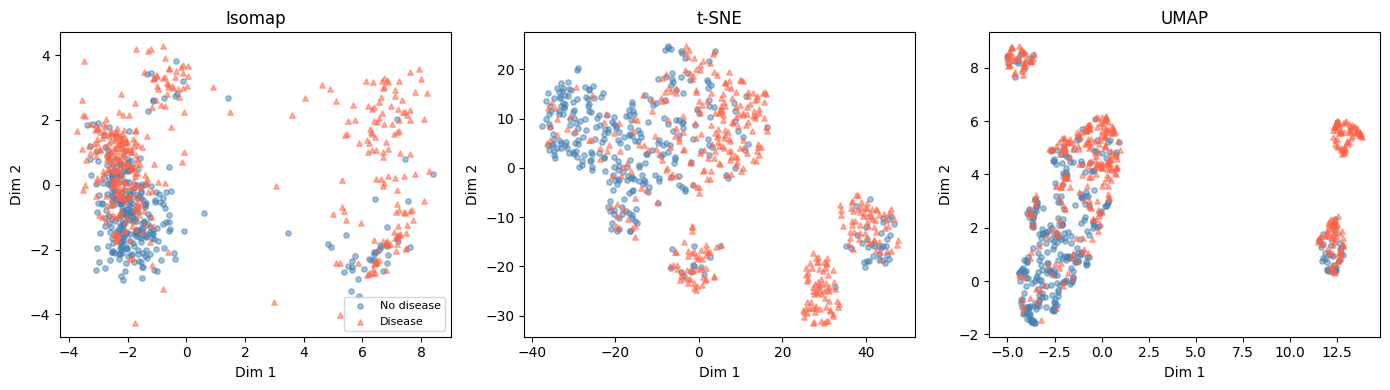

In [9]:
from sklearn.manifold import Isomap, TSNE
import umap

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

metodos = {
    'Isomap': Isomap(n_components=2, n_neighbors=15),
    't-SNE':  TSNE(n_components=2, perplexity=30, random_state=SEED),
    'UMAP':   umap.UMAP(n_components=2, random_state=SEED),
}

for ax, (name, modelo) in zip(axes, metodos.items()):
    X_2d = modelo.fit_transform(X_train_num)
    for label, color, marker, lname in [
        (0, 'steelblue', 'o', 'No disease'),
        (1, 'tomato',    '^', 'Disease')
    ]:
        mask = y_train.values == label
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=color, marker=marker, alpha=0.5, s=15, label=lname)
    ax.set_title(name)
    ax.set_xlabel('Dim 1')
    ax.set_ylabel('Dim 2')

axes[0].legend(fontsize=8)
plt.tight_layout()
plt.savefig('p2a_proyecciones.pdf')
plt.show()

(b)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


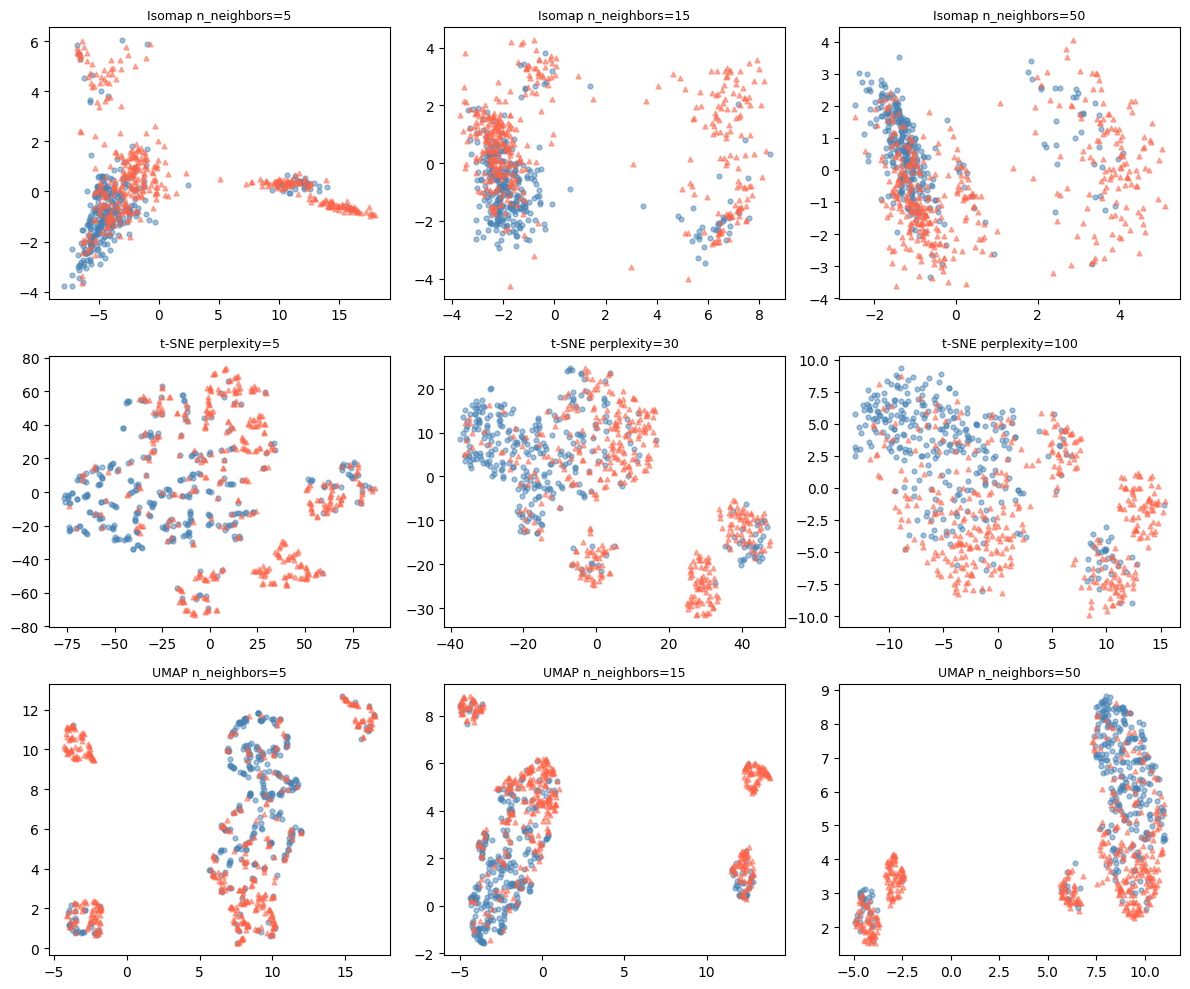

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


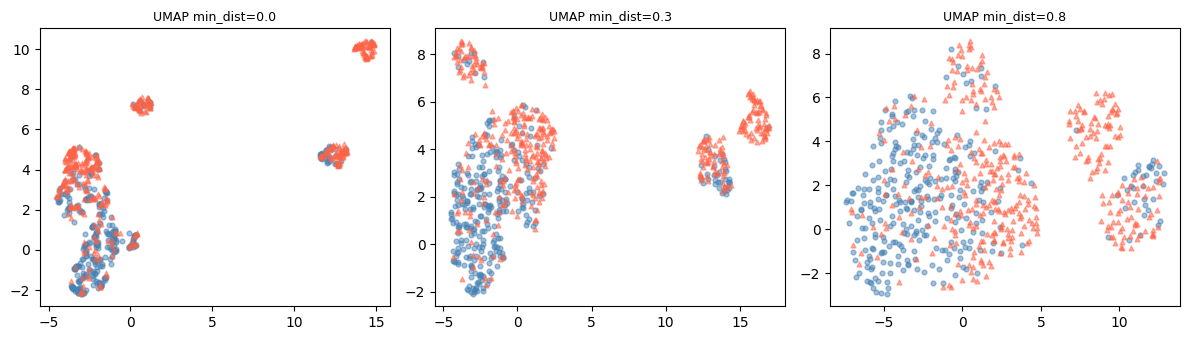

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(12, 10))

# Isomap: n_neighbors en {5, 15, 50}
for ax, nn in zip(axes[0], [5, 15, 50]):
    X_2d = Isomap(n_components=2, n_neighbors=nn).fit_transform(X_train_num)
    for label, color, marker in [(0,'steelblue','o'),(1,'tomato','^')]:
        mask = y_train.values == label
        ax.scatter(X_2d[mask,0], X_2d[mask,1], c=color, marker=marker, alpha=0.5, s=12)
    ax.set_title(f'Isomap n_neighbors={nn}', fontsize=9)

# t-SNE: perplexity en {5, 30, 100}
for ax, perp in zip(axes[1], [5, 30, 100]):
    X_2d = TSNE(n_components=2, perplexity=perp, random_state=SEED).fit_transform(X_train_num)
    for label, color, marker in [(0,'steelblue','o'),(1,'tomato','^')]:
        mask = y_train.values == label
        ax.scatter(X_2d[mask,0], X_2d[mask,1], c=color, marker=marker, alpha=0.5, s=12)
    ax.set_title(f't-SNE perplexity={perp}', fontsize=9)

# UMAP: n_neighbors en {5, 15, 50} con min_dist=0.1
for ax, nn in zip(axes[2], [5, 15, 50]):
    X_2d = umap.UMAP(n_components=2, n_neighbors=nn, min_dist=0.1, random_state=SEED).fit_transform(X_train_num)
    for label, color, marker in [(0,'steelblue','o'),(1,'tomato','^')]:
        mask = y_train.values == label
        ax.scatter(X_2d[mask,0], X_2d[mask,1], c=color, marker=marker, alpha=0.5, s=12)
    ax.set_title(f'UMAP n_neighbors={nn}', fontsize=9)

plt.tight_layout()
plt.savefig('p2b_neighbors.pdf')
plt.show()

# UMAP: min_dist en {0.0, 0.3, 0.8} con n_neighbors=15
fig2, axes2 = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, md in zip(axes2, [0.0, 0.3, 0.8]):
    X_2d = umap.UMAP(n_components=2, n_neighbors=15, min_dist=md, random_state=SEED).fit_transform(X_train_num)
    for label, color, marker in [(0,'steelblue','o'),(1,'tomato','^')]:
        mask = y_train.values == label
        ax.scatter(X_2d[mask,0], X_2d[mask,1], c=color, marker=marker, alpha=0.5, s=12)
    ax.set_title(f'UMAP min_dist={md}', fontsize=9)

plt.tight_layout()
plt.savefig('p2b_mindist.pdf')
plt.show()